PROCESO OPTIMIZADO CON MLP - SOLO VARIABLES EPIDEMIOLÓGICAS
OBJETIVOS: MAE < 3 | Peak MAE < 5 | R² > 0.86

Cargando datos de entrenamiento desde: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20\2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_80_20.xlsx
Datos de entrenamiento: 216 muestras, 171 características
INGENIERÍA DE ATRIBUTOS - SOLO VARIABLES EPIDEMIOLÓGICAS
Variables epidemiológicas con rezago: 12
Características después de ingeniería: 67
Escalando características...

BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS
Objetivos: MAE < 3 | Peak MAE < 5 | R² > 0.86

Probando con 5 características...
  MAE: 12.5081, R²: 0.5765, RMSE: 16.0121
  MAE en picos (>P90): 18.4650

Probando con 8 características...
  MAE: 7.5070, R²: 0.7844, RMSE: 11.4249
  MAE en picos (>P90): 16.3904

Probando con 11 características...
  MAE: 7.6801, R²: 0.7515, RMSE: 12.2662
  MAE en picos (>P90): 18.6557

Probando con 14 caracterís

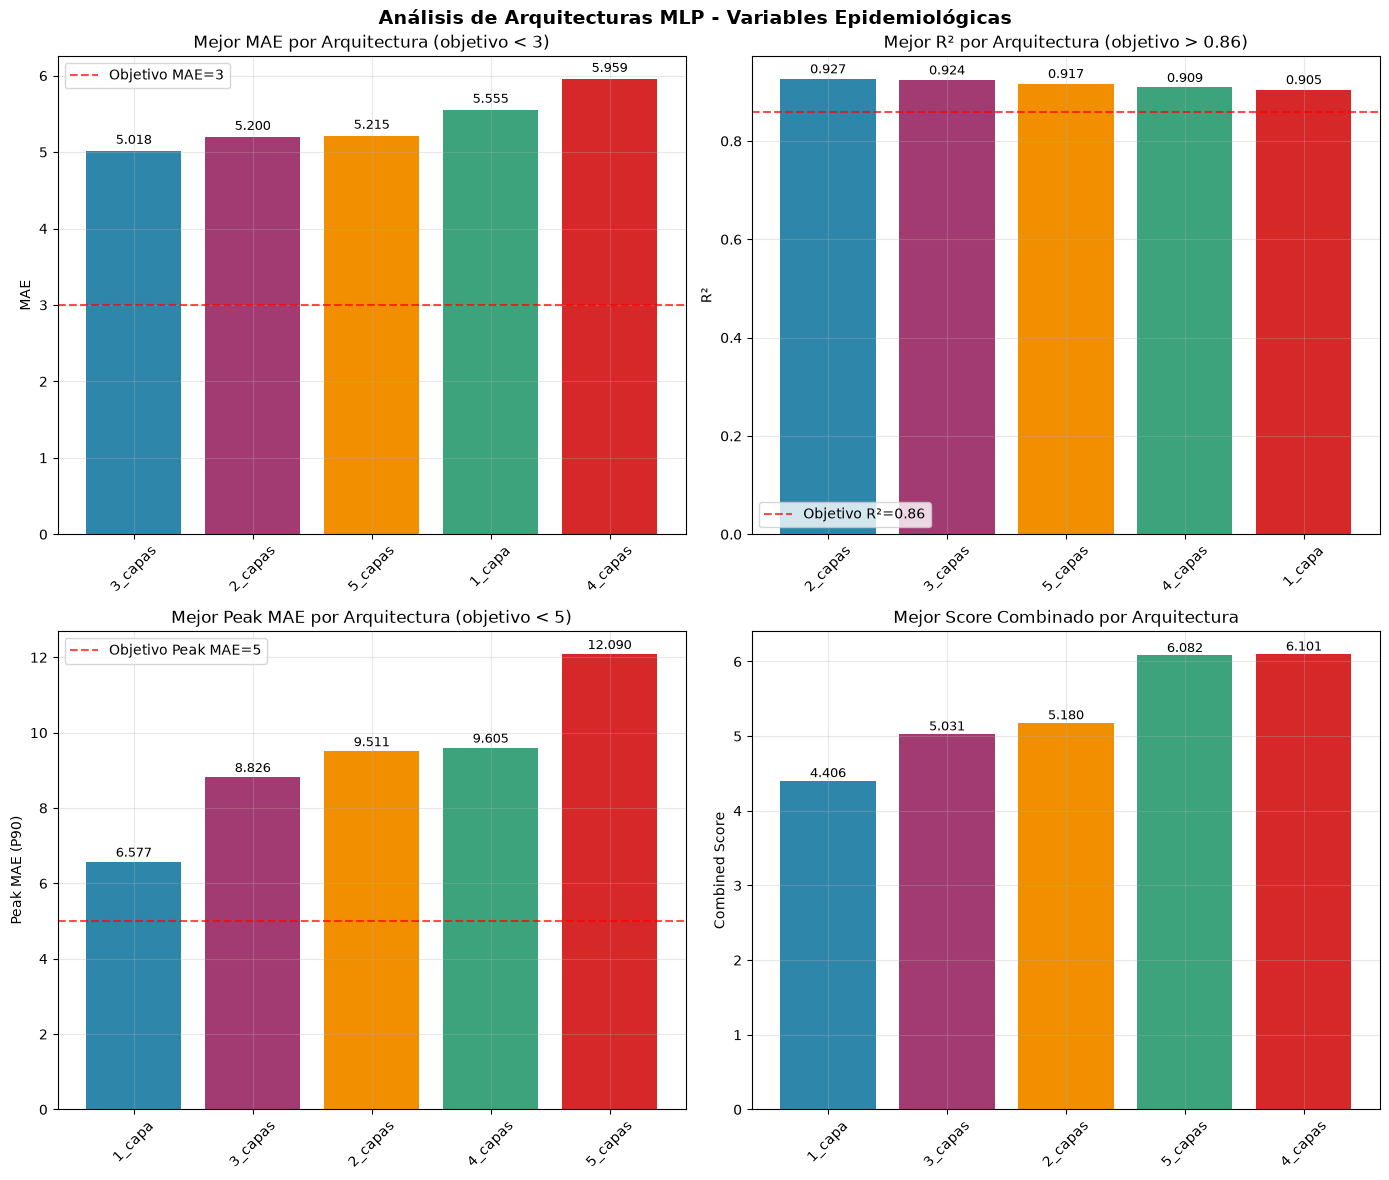

✅ Gráfico de selección guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20\feature_selection_analysis_epi_20260916_085809.png


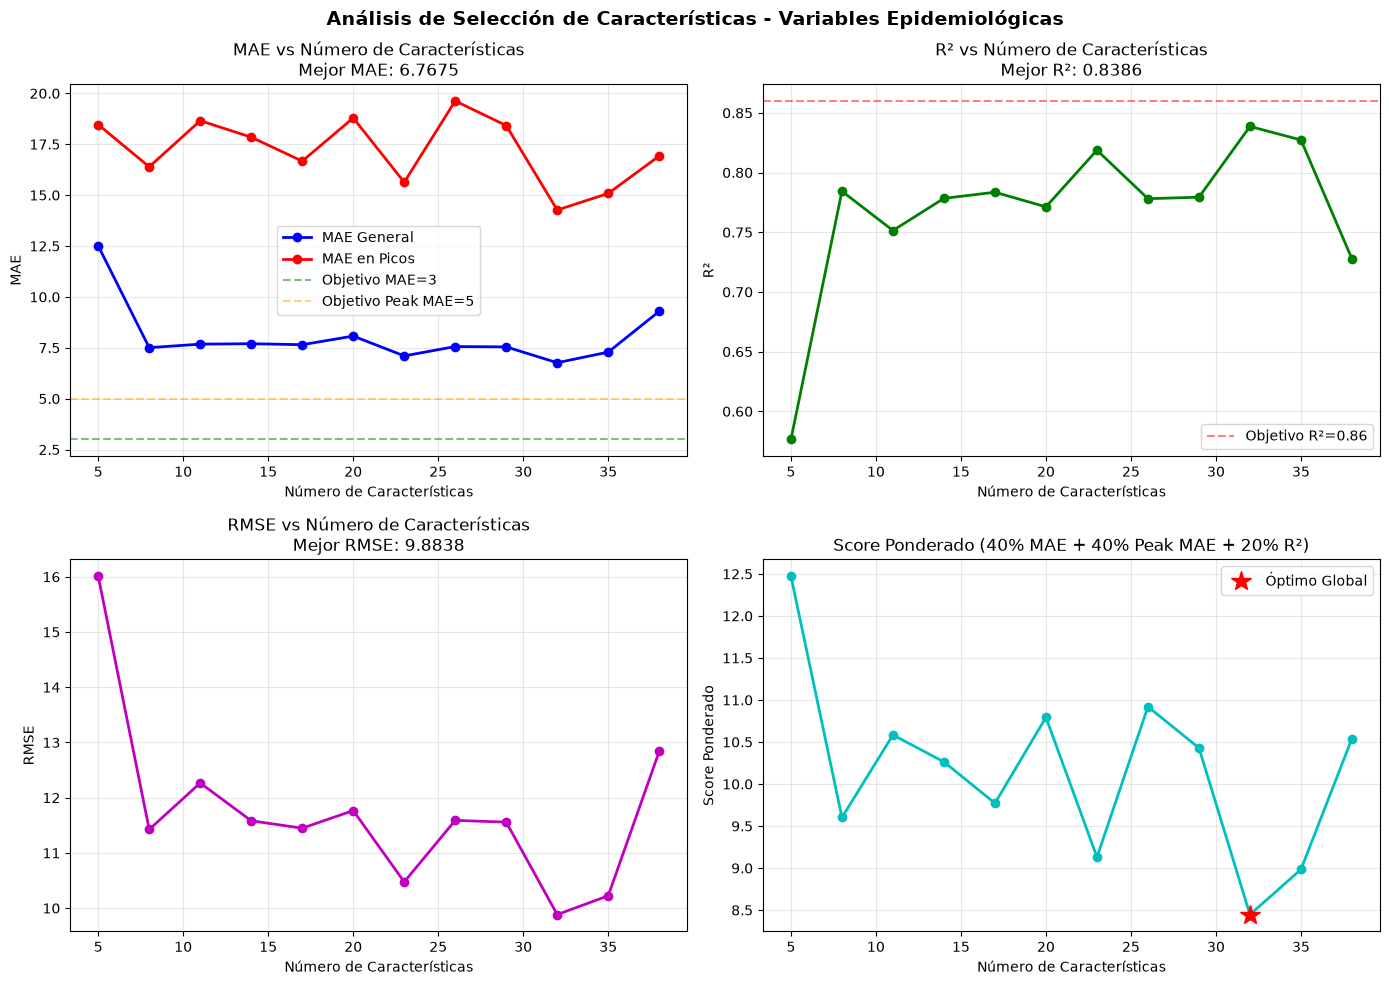

✅ Análisis de picos guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20\peak_analysis_epi_20260916_085809.png


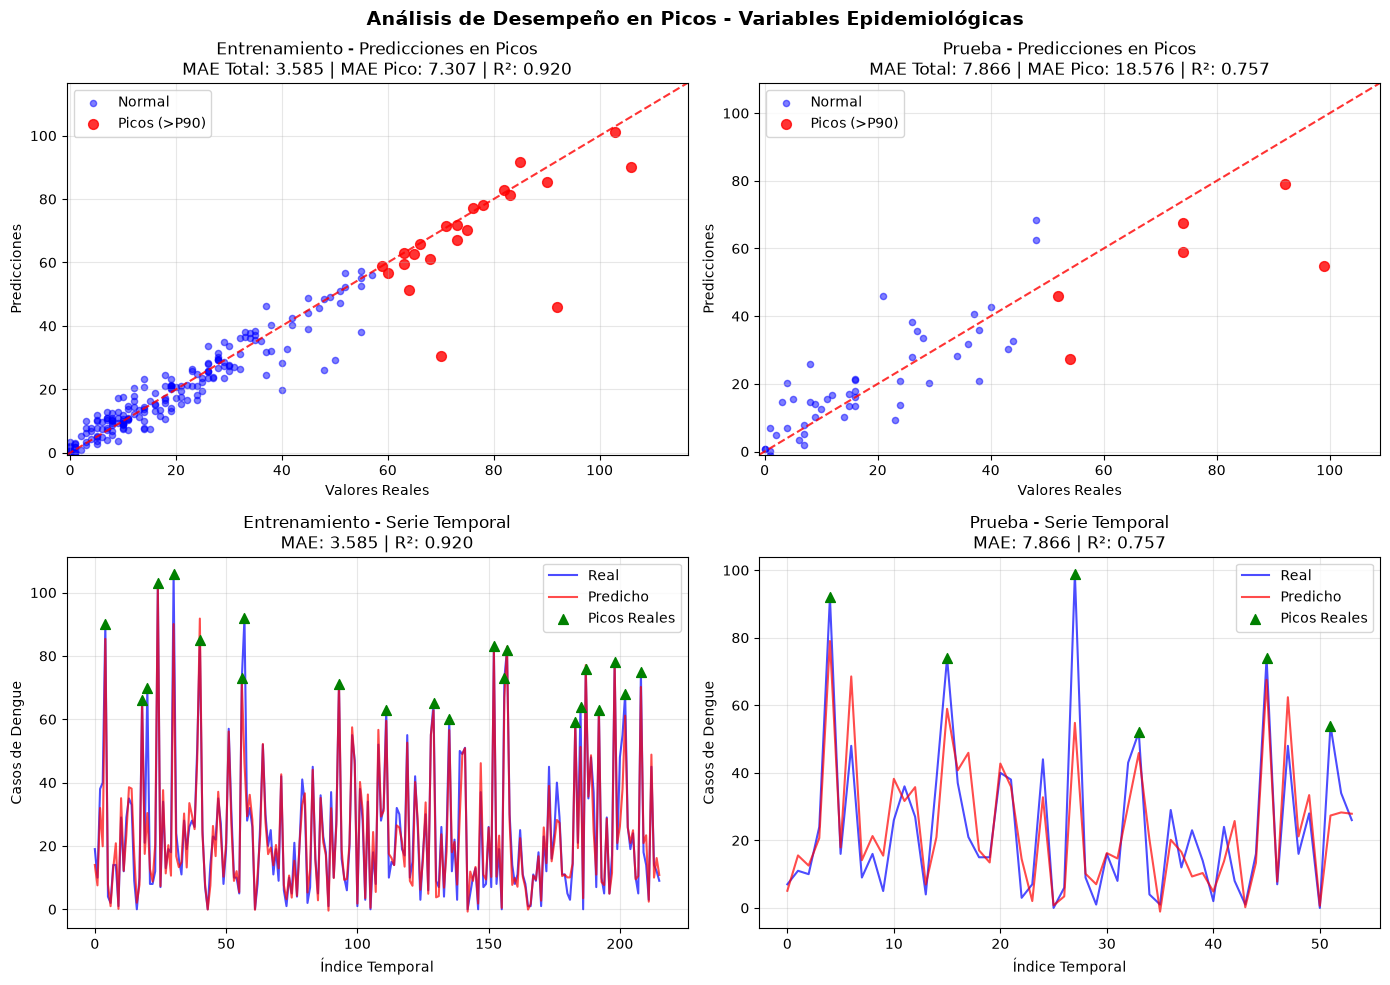

✅ Comparación guardada en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20\performance_comparison_epi_20260916_085809.png


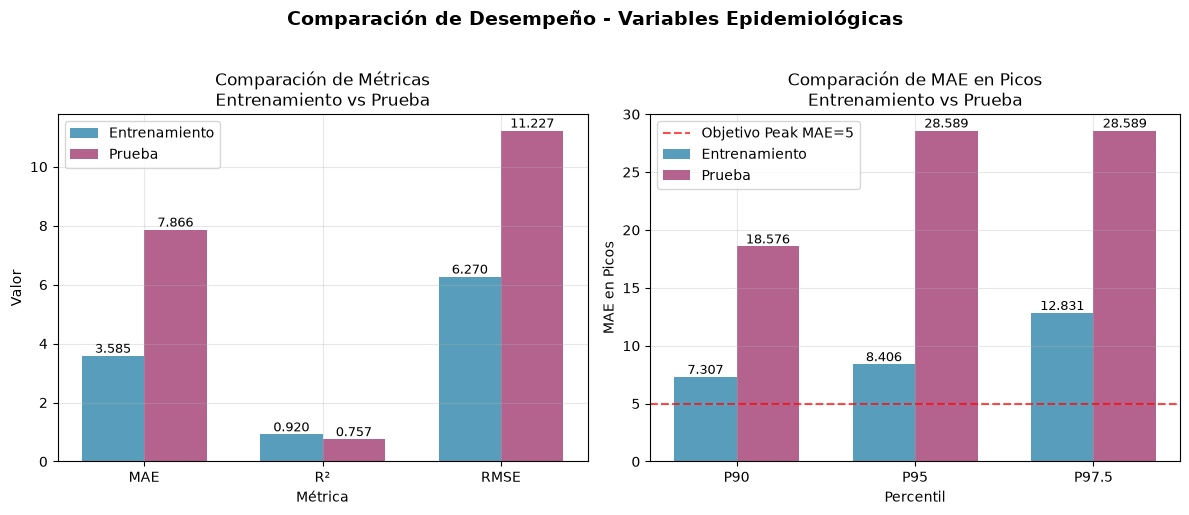

✅ Script de despliegue MLP (epidemiológico) generado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20\modelo_mlp_epidemiologico_despliegue.py

PROCESO MLP EPIDEMIOLÓGICO COMPLETADO EXITOSAMENTE
Resultados guardados en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20\resultados_mlp_epidemiologico_20260916_085809.xlsx
Análisis de arquitecturas: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20\architecture_analysis_epi_20260916_085809.png
Análisis de selección: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20\feature_selection_analysis_epi_20260916_085809.png
Análisis de picos: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_dato

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
import warnings
import os
from datetime import datetime
import json
import pickle
from itertools import product
import time

warnings.filterwarnings('ignore')

# ==========================================
# VARIABLES EPIDEMIOLÓGICAS CON REZAGO
# ==========================================
EPIDEMIOLOGICAL_LAG_VARS = [f'casos_dengue_lag_{i}' for i in range(1, 13)]


class DengueFeatureEngineeringEpidemiological:
    """
    Clase optimizada para ingeniería de atributos usando MLP (Red Neuronal)
    EXCLUSIVAMENTE con variables epidemiológicas con rezago.
    Objetivo: MAE < 3, Peak MAE < 5, R² > 0.86
    """
    def __init__(self, n_features_to_select=20):
        self.n_features_to_select = n_features_to_select
        self.scaler = StandardScaler()
        self.rfe = None
        self.selected_features = None
        self.feature_names = None
        self.mlp_model = None
        self.numeric_columns = None
        self.feature_importance_df = None
        self.best_params = None
        self.peak_mae = None
        self.X_augmented_columns = None
        self.best_metrics = None
        self.all_features_importance = None
        self.cv_results = None
        self.train_val_metrics = None
        self.architecture_results = None
        self.best_architecture = None
        self.feature_selection_results = None
        self.epidemiological_cols = None

    # --------------------------------------------------
    # FILTRADO DE VARIABLES EPIDEMIOLÓGICAS
    # --------------------------------------------------
    def get_epidemiological_columns(self, X):
        """
        Filtra únicamente las columnas epidemiológicas con rezago.
        Excluye fecha, año, semana_epi y cualquier variable no epidemiológica.
        """
        epi_cols = []
        exclude_exact = {'fecha', 'date', 'datetime', 'timestamp',
                         'año', 'ano', 'year', 'semana_epi', 'semana',
                         'casos_dengue'}

        for col in X.columns:
            col_lower = col.lower()
            if col_lower in exclude_exact:
                continue
            # Incluir únicamente casos_dengue_lag_N
            if col.startswith('casos_dengue_lag_'):
                epi_cols.append(col)

        # Ordenar por número de rezago
        try:
            epi_cols = sorted(epi_cols,
                              key=lambda c: int(c.split('_')[-1]))
        except Exception:
            pass

        return epi_cols

    # --------------------------------------------------
    # INGENIERÍA DE ATRIBUTOS ESPECIALIZADA
    # --------------------------------------------------
    def create_lag_aggregates(self, X):
        """Crea agregados de rezagos (media, std, max, min, mediana)"""
        lag_aggs = pd.DataFrame(index=X.index)

        dengue_lag_cols = [c for c in X.columns
                           if c.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = lag_data.sum(axis=1)
            lag_aggs['dengue_lag_max'] = lag_data.max(axis=1)
            lag_aggs['dengue_lag_min'] = lag_data.min(axis=1)
            lag_aggs['dengue_lag_median'] = lag_data.median(axis=1)
            lag_aggs['dengue_lag_range'] = (
                lag_aggs['dengue_lag_max'] - lag_aggs['dengue_lag_min']
            )
            lag_aggs['dengue_lag_cv'] = (
                lag_aggs['dengue_lag_std'] / (lag_aggs['dengue_lag_mean'] + 1e-6)
            )

        # Agregados por ventanas temporales
        for window, name in [(3, 'short'), (6, 'mid'), (12, 'long')]:
            cols = [f'casos_dengue_lag_{i}' for i in range(1, window + 1)]
            cols = [c for c in cols if c in X.columns]
            if len(cols) == window:
                window_data = X[cols]
                lag_aggs[f'dengue_{name}_mean'] = window_data.mean(axis=1)
                lag_aggs[f'dengue_{name}_std'] = window_data.std(axis=1)
                lag_aggs[f'dengue_{name}_max'] = window_data.max(axis=1)
                lag_aggs[f'dengue_{name}_sum'] = window_data.sum(axis=1)

        return lag_aggs

    def create_trend_features(self, X):
        """
        Crea características de tendencia temporal epidemiológica:
        diferencias entre rezagos consecutivos y ventanas.
        """
        trend_features = pd.DataFrame(index=X.index)

        # Diferencias consecutivas (velocidad de cambio)
        for i in range(1, 12):
            col_curr = f'casos_dengue_lag_{i}'
            col_next = f'casos_dengue_lag_{i + 1}'
            if col_curr in X.columns and col_next in X.columns:
                trend_features[f'dengue_diff_{i}_{i+1}'] = X[col_curr] - X[col_next]

        # Tendencias por ventanas
        if 'casos_dengue_lag_1' in X.columns and 'casos_dengue_lag_4' in X.columns:
            trend_features['dengue_trend_short'] = (
                X['casos_dengue_lag_1'] - X['casos_dengue_lag_4']
            )
        if 'casos_dengue_lag_4' in X.columns and 'casos_dengue_lag_8' in X.columns:
            trend_features['dengue_trend_mid'] = (
                X['casos_dengue_lag_4'] - X['casos_dengue_lag_8']
            )
        if 'casos_dengue_lag_8' in X.columns and 'casos_dengue_lag_12' in X.columns:
            trend_features['dengue_trend_long'] = (
                X['casos_dengue_lag_8'] - X['casos_dengue_lag_12']
            )

        # Aceleración (segunda diferencia)
        if ('casos_dengue_lag_1' in X.columns and
            'casos_dengue_lag_2' in X.columns and
                'casos_dengue_lag_3' in X.columns):
            trend_features['dengue_acceleration'] = (
                X['casos_dengue_lag_1'] - 2 * X['casos_dengue_lag_2'] +
                X['casos_dengue_lag_3']
            )

        return trend_features

    def create_ratio_features(self, X):
        """Crea ratios entre rezagos (importante para brotes)"""
        ratio_features = pd.DataFrame(index=X.index)

        ratios = [
            ('casos_dengue_lag_1', 'casos_dengue_lag_2', 'dengue_ratio_1_2'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_4', 'dengue_ratio_1_4'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_12', 'dengue_ratio_1_12'),
            ('casos_dengue_lag_2', 'casos_dengue_lag_4', 'dengue_ratio_2_4'),
            ('casos_dengue_lag_4', 'casos_dengue_lag_12', 'dengue_ratio_4_12'),
        ]

        for col1, col2, new_col in ratios:
            if col1 in X.columns and col2 in X.columns:
                ratio_features[new_col] = (
                    X[col1] / (X[col2] + 1.0)
                )

        return ratio_features

    def create_rolling_features(self, X):
        """Crea características de tendencia temporal simplificadas"""
        rolling_features = pd.DataFrame(index=X.index)

        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)

        return rolling_features

    def create_polynomial_features(self, X):
        """Crea características polinomiales para rezagos clave"""
        important_lags = ['casos_dengue_lag_1', 'casos_dengue_lag_2',
                          'casos_dengue_lag_4', 'casos_dengue_lag_12']
        poly_features = pd.DataFrame(index=X.index)

        for var in important_lags:
            if var in X.columns:
                poly_features[f'{var}_squared'] = X[var] ** 2
                poly_features[f'{var}_sqrt'] = np.sqrt(np.abs(X[var]))

        return poly_features

    def create_interaction_features(self, X):
        """Crea interacciones entre rezagos clave"""
        interaction_data = pd.DataFrame(index=X.index)

        interactions = [
            ('casos_dengue_lag_1', 'casos_dengue_lag_2', 'lag1_lag2'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_4', 'lag1_lag4'),
            ('casos_dengue_lag_2', 'casos_dengue_lag_4', 'lag2_lag4'),
            ('casos_dengue_lag_4', 'casos_dengue_lag_12', 'lag4_lag12'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_12', 'lag1_lag12'),
        ]

        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]

        return interaction_data

    def get_numeric_columns(self, X):
        """Identifica columnas numéricas"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []

        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)

        return numeric_cols

    def augment_features(self, X):
        """Aplica ingeniería de atributos SOLO con variables epidemiológicas"""
        # Filtrar SOLO columnas epidemiológicas con rezago
        epi_cols = self.get_epidemiological_columns(X)
        self.epidemiological_cols = epi_cols
        X_epi = X[epi_cols].copy()

        # Eliminar columnas con todos NaN
        X_epi = X_epi.dropna(axis=1, how='all')

        features_list = [X_epi]

        # Agregados de rezagos
        lag_aggs = self.create_lag_aggregates(X_epi)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)

        # Tendencias
        trend_features = self.create_trend_features(X_epi)
        if not trend_features.empty:
            features_list.append(trend_features)

        # Ratios
        ratio_features = self.create_ratio_features(X_epi)
        if not ratio_features.empty:
            features_list.append(ratio_features)

        # Polinomiales
        poly_features = self.create_polynomial_features(X_epi)
        if not poly_features.empty:
            features_list.append(poly_features)

        # Interacciones
        interaction_features = self.create_interaction_features(X_epi)
        if not interaction_features.empty:
            features_list.append(interaction_features)

        # Rolling (semana_epi si existe)
        rolling_features = self.create_rolling_features(X)
        if not rolling_features.empty:
            features_list.append(rolling_features)

        X_augmented = pd.concat(features_list, axis=1)

        # Limpiar infinitos y NaN
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        X_augmented = X_augmented.fillna(0)

        return X_augmented, X_epi

    def fit_transform(self, X, y=None):
        """Aplica transformaciones con regularización"""
        print("=" * 60)
        print("INGENIERÍA DE ATRIBUTOS - SOLO VARIABLES EPIDEMIOLÓGICAS")
        print("=" * 60)

        X_augmented, X_epi = self.augment_features(X)

        self.numeric_columns = X_epi.columns.tolist()
        self.X_augmented_columns = X_augmented.columns.tolist()
        self.feature_names = X_augmented.columns.tolist()

        print(f"Variables epidemiológicas con rezago: {X_epi.shape[1]}")
        print(f"Características después de ingeniería: {X_augmented.shape[1]}")

        print("Escalando características...")
        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )

        return X_scaled, X_augmented

    def transform_features(self, X):
        """Aplica transformación a nuevos datos"""
        X_augmented, X_epi = self.augment_features(X)

        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0

        X_augmented = X_augmented[self.X_augmented_columns]

        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )

        return X_scaled

    def find_optimal_features(self, X_scaled, y, feature_range=None):
        """
        Encuentra el número óptimo de características con enfoque en:
        MAE general < 3, Peak MAE < 5, R² > 0.86
        """
        if feature_range is None:
            feature_range = range(5, min(40, X_scaled.shape[1]), 3)

        print("\n" + "=" * 60)
        print("BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS")
        print("Objetivos: MAE < 3 | Peak MAE < 5 | R² > 0.86")
        print("=" * 60)

        results = []
        best_score = float('inf')
        best_peak_mae = float('inf')
        best_n_features = None
        best_rfe = None
        best_selected = None
        best_metrics = None

        X_train_val, X_val, y_train_val, y_val = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

        for n_features in feature_range:
            print(f"\nProbando con {n_features} características...")

            rf = RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                min_samples_split=8,
                min_samples_leaf=4,
                random_state=42,
                n_jobs=-1
            )

            rfe = RFE(
                estimator=rf,
                n_features_to_select=n_features,
                step=2,
                verbose=0
            )

            X_train_selected = rfe.fit_transform(X_train_val, y_train_val)
            X_val_selected = rfe.transform(X_val)

            # MLP base para evaluar (más profundo)
            model = MLPRegressor(
                hidden_layer_sizes=(128, 64, 32),
                activation='relu',
                solver='adam',
                alpha=0.0005,
                batch_size='auto',
                learning_rate='adaptive',
                learning_rate_init=0.001,
                max_iter=500,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20
            )
            model.fit(X_train_selected, y_train_val)

            y_pred = model.predict(X_val_selected)

            mae = mean_absolute_error(y_val, y_pred)
            r2 = r2_score(y_val, y_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))

            peak_threshold = np.percentile(y_val, 90)
            peak_mask = y_val > peak_threshold
            peak_mae = (mean_absolute_error(y_val[peak_mask], y_pred[peak_mask])
                        if np.sum(peak_mask) > 0 else float('inf'))

            print(f"  MAE: {mae:.4f}, R²: {r2:.4f}, RMSE: {rmse:.4f}")
            print(f"  MAE en picos (>P90): {peak_mae:.4f}")

            results.append({
                'n_features': n_features,
                'mae': mae,
                'r2': r2,
                'rmse': rmse,
                'peak_mae': peak_mae,
                'peak_threshold': peak_threshold,
                'n_peaks': int(np.sum(peak_mask))
            })

            # Score ponderado alineado con objetivos:
            # 40% MAE general, 40% Peak MAE, 20% (1-R²)
            if peak_mae != float('inf'):
                weighted_score = (0.4 * mae + 0.4 * peak_mae +
                                  0.2 * (1 - r2))
            else:
                weighted_score = 0.6 * mae + 0.4 * (1 - r2)

            if weighted_score < best_score:
                best_score = weighted_score
                best_peak_mae = peak_mae
                best_n_features = n_features
                best_rfe = rfe
                best_selected = X_scaled.columns[rfe.support_].tolist()
                best_metrics = {
                    'mae': mae, 'r2': r2, 'rmse': rmse,
                    'peak_mae': peak_mae
                }

        print("\n" + "=" * 60)
        print(f"✅ NÚMERO ÓPTIMO DE CARACTERÍSTICAS: {best_n_features}")
        print(f"   MAE: {best_metrics['mae']:.4f}")
        print(f"   R²: {best_metrics['r2']:.4f}")
        print(f"   RMSE: {best_metrics['rmse']:.4f}")
        print(f"   MAE en picos: {best_metrics['peak_mae']:.4f}")
        print("=" * 60)

        self.selected_features = best_selected
        self.rfe = best_rfe
        self.best_metrics = best_metrics
        self.feature_selection_results = pd.DataFrame(results)

        return best_n_features, results, best_metrics

    def transform_with_selected_features(self, X_scaled):
        """Transforma usando las características seleccionadas"""
        return X_scaled[self.selected_features]

    def find_best_architecture(self, X_train, y_train, X_test, y_test):
        """
        Busca la mejor arquitectura de red neuronal evaluando diferentes
        números de capas y neuronas por capa.
        Optimizado para MAE < 3, Peak MAE < 5, R² > 0.86
        """
        print("\n" + "=" * 60)
        print("BÚSQUEDA DE LA MEJOR ARQUITECTURA DE RED NEURONAL")
        print("Objetivos: MAE < 3 | Peak MAE < 5 | R² > 0.86")
        print("=" * 60)

        # Arquitecturas más profundas y con capacidad
        architectures = {
            '1_capa': {
                'hidden_layer_sizes': [(32,), (64,), (128,), (256,)],
                'desc': '1 capa oculta'
            },
            '2_capas': {
                'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128),
                                       (512, 256)],
                'desc': '2 capas ocultas'
            },
            '3_capas': {
                'hidden_layer_sizes': [(128, 64, 32), (256, 128, 64),
                                       (512, 256, 128)],
                'desc': '3 capas ocultas'
            },
            '4_capas': {
                'hidden_layer_sizes': [(256, 128, 64, 32),
                                       (512, 256, 128, 64)],
                'desc': '4 capas ocultas'
            },
            '5_capas': {
                'hidden_layer_sizes': [(256, 128, 64, 32, 16),
                                       (512, 256, 128, 64, 32)],
                'desc': '5 capas ocultas'
            }
        }

        # Múltiples combinaciones de regularización
        alpha_values = [0.0001, 0.0005, 0.001]

        results = []
        total_configs = sum(len(arch['hidden_layer_sizes'])
                            for arch in architectures.values()) * len(alpha_values)
        print(f"\nEvaluando {total_configs} configuraciones diferentes...")
        print("-" * 60)

        best_score = float('inf')
        best_config = None
        best_model = None
        best_metrics = None

        config_counter = 0

        for arch_name, arch_config in architectures.items():
            print(f"\n{arch_config['desc']} ({arch_name}):")

            for hidden_layers in arch_config['hidden_layer_sizes']:
                for alpha in alpha_values:
                    config_counter += 1
                    print(f"  [{config_counter}/{total_configs}] "
                          f"Capas: {hidden_layers}, alpha={alpha}",
                          end="", flush=True)

                    try:
                        start_time = time.time()
                        model = MLPRegressor(
                            hidden_layer_sizes=hidden_layers,
                            activation='relu',
                            solver='adam',
                            alpha=alpha,
                            learning_rate='adaptive',
                            learning_rate_init=0.001,
                            max_iter=1000,
                            random_state=42,
                            early_stopping=True,
                            validation_fraction=0.15,
                            n_iter_no_change=30,
                            batch_size='auto'
                        )
                        model.fit(X_train, y_train)
                        train_time = time.time() - start_time

                        y_pred_test = model.predict(X_test)
                        y_pred_train = model.predict(X_train)

                        mae_test = mean_absolute_error(y_test, y_pred_test)
                        r2_test = r2_score(y_test, y_pred_test)
                        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
                        mae_train = mean_absolute_error(y_train, y_pred_train)
                        r2_train = r2_score(y_train, y_pred_train)

                        # MAE en picos
                        peak_threshold = np.percentile(y_test, 90)
                        peak_mask = y_test > peak_threshold
                        if np.sum(peak_mask) > 0:
                            peak_mae_test = mean_absolute_error(
                                y_test[peak_mask], y_pred_test[peak_mask]
                            )
                        else:
                            peak_mae_test = float('inf')

                        # Score combinado alineado con objetivos
                        # MAE < 3, Peak MAE < 5, R² > 0.86
                        if peak_mae_test != float('inf'):
                            combined_score = (
                                0.35 * mae_test +
                                0.35 * peak_mae_test +
                                0.30 * (1 - r2_test)
                            )
                        else:
                            combined_score = (
                                0.5 * mae_test + 0.5 * (1 - r2_test)
                            )

                        print(f" | MAE: {mae_test:.3f} | "
                              f"Peak MAE: {peak_mae_test:.3f} | "
                              f"R²: {r2_test:.3f} | "
                              f"Score: {combined_score:.3f} | "
                              f"Tiempo: {train_time:.1f}s")

                        results.append({
                            'architecture': arch_name,
                            'layers': str(hidden_layers),
                            'n_layers': len(hidden_layers),
                            'neurons': hidden_layers,
                            'alpha': alpha,
                            'mae_train': mae_train,
                            'r2_train': r2_train,
                            'mae_test': mae_test,
                            'r2_test': r2_test,
                            'rmse_test': rmse_test,
                            'peak_mae_test': peak_mae_test,
                            'combined_score': combined_score,
                            'train_time': train_time,
                            'model': model
                        })

                        if combined_score < best_score:
                            best_score = combined_score
                            best_config = {
                                'architecture': arch_name,
                                'hidden_layers': hidden_layers,
                                'n_layers': len(hidden_layers),
                                'neurons': hidden_layers,
                                'alpha': alpha
                            }
                            best_model = model
                            best_metrics = {
                                'mae_train': mae_train,
                                'r2_train': r2_train,
                                'mae_test': mae_test,
                                'r2_test': r2_test,
                                'rmse_test': rmse_test,
                                'peak_mae_test': peak_mae_test,
                                'combined_score': combined_score,
                                'train_time': train_time
                            }

                    except Exception as e:
                        print(f" | Error: {str(e)[:50]}")
                        continue

        # Resumen
        print("\n" + "=" * 60)
        print("RESUMEN DE MEJORES MODELOS POR ARQUITECTURA")
        print("=" * 60)

        df_results = pd.DataFrame([
            {k: v for k, v in r.items() if k not in ('model', 'neurons')}
            for r in results
        ])

        if not df_results.empty:
            best_by_arch = df_results.loc[
                df_results.groupby('architecture')['combined_score'].idxmin()
            ]

            print("\nMejor modelo por tipo de arquitectura:")
            print("-" * 60)
            for _, row in best_by_arch.iterrows():
                print(f"  {row['architecture']}: "
                      f"MAE={row['mae_test']:.3f}, "
                      f"Peak MAE={row['peak_mae_test']:.3f}, "
                      f"R²={row['r2_test']:.3f}")

            print("\nTop 5 mejores modelos generales:")
            print("-" * 60)
            top5 = df_results.nsmallest(5, 'combined_score')
            for idx, (_, row) in enumerate(top5.iterrows(), 1):
                print(f"  #{idx}: {row['architecture']} | "
                      f"Capas: {row['layers']} | "
                      f"alpha: {row['alpha']} | "
                      f"MAE: {row['mae_test']:.3f} | "
                      f"Peak MAE: {row['peak_mae_test']:.3f} | "
                      f"R²: {row['r2_test']:.3f}")

        self.architecture_results = pd.DataFrame(results)
        self.best_architecture = best_config
        self.mlp_model = best_model

        print("\n" + "=" * 60)
        print("✅ MEJOR ARQUITECTURA ENCONTRADA:")
        print("=" * 60)
        print(f"  Arquitectura: {best_config['architecture']}")
        print(f"  Capas ocultas: {best_config['hidden_layers']}")
        print(f"  Número de capas: {best_config['n_layers']}")
        print(f"  Neuronas por capa: {best_config['neurons']}")
        print(f"  Alpha (regularización): {best_config['alpha']}")
        print(f"\n  MAE Test: {best_metrics['mae_test']:.4f}")
        print(f"  R² Test: {best_metrics['r2_test']:.4f}")
        print(f"  Peak MAE Test: {best_metrics['peak_mae_test']:.4f}")
        print(f"  Combined Score: {best_metrics['combined_score']:.4f}")
        print("=" * 60)

        self.best_metrics = {
            'mae': best_metrics['mae_test'],
            'r2': best_metrics['r2_test'],
            'rmse': best_metrics['rmse_test'],
            'peak_mae': best_metrics['peak_mae_test']
        }

        self.train_val_metrics = {
            'mae_train': best_metrics['mae_train'],
            'r2_train': best_metrics['r2_train'],
            'mae_test': best_metrics['mae_test'],
            'r2_test': best_metrics['r2_test'],
            'peak_mae_test': best_metrics['peak_mae_test'],
            'overfit_gap': best_metrics['mae_test'] - best_metrics['mae_train'],
            'best_params': {
                'hidden_layer_sizes': best_config['hidden_layers'],
                'activation': 'relu',
                'solver': 'adam',
                'alpha': best_config['alpha'],
                'learning_rate': 'adaptive',
                'learning_rate_init': 0.001,
                'max_iter': 1000,
                'early_stopping': True,
                'validation_fraction': 0.15,
                'n_iter_no_change': 30
            }
        }

        return best_config, best_model, best_metrics

    def evaluate_model_detailed(self, X_test, y_test, dataset_name="Test"):
        """Evalúa el modelo con métricas detalladas incluyendo picos"""
        y_pred = self.mlp_model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        peak_metrics = {}
        for p in [90, 95, 97.5]:
            threshold = np.percentile(y_test, p)
            peak_mask = y_test > threshold
            if np.sum(peak_mask) > 0:
                peak_mae = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
                peak_r2 = (r2_score(y_test[peak_mask], y_pred[peak_mask])
                           if len(y_test[peak_mask]) > 1 else np.nan)
                peak_metrics[f'P{p}_MAE'] = peak_mae
                peak_metrics[f'P{p}_R2'] = peak_r2
                peak_metrics[f'P{p}_Threshold'] = threshold
                peak_metrics[f'P{p}_Count'] = int(np.sum(peak_mask))

        print(f"\n{'='*60}")
        print(f"MÉTRICAS DETALLADAS - {dataset_name}")
        print(f"{'='*60}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"\nMétricas para picos:")
        for key, value in peak_metrics.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")

        return {
            'MAE': mae,
            'R2': r2,
            'RMSE': rmse,
            'peak_metrics': peak_metrics,
            'predictions': y_pred,
            'actual': y_test.values if hasattr(y_test, 'values') else y_test
        }


# ==========================================
# FUNCIONES DE GRAFICACIÓN
# ==========================================

def plot_architecture_results(architecture_results, save_path=None):
    """Grafica los resultados de la búsqueda de arquitecturas"""
    if architecture_results is None or len(architecture_results) == 0:
        print("No hay resultados de arquitecturas para graficar")
        return None

    df = architecture_results.copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#3CA37C', '#D62828']

    # 1. MAE por arquitectura
    ax1 = axes[0, 0]
    architectures = df.groupby('architecture')['mae_test'].min().sort_values()
    bars = ax1.bar(range(len(architectures)), architectures.values,
                   color=colors[:len(architectures)])
    ax1.set_xticks(range(len(architectures)))
    ax1.set_xticklabels(architectures.index, rotation=45)
    ax1.set_ylabel('MAE')
    ax1.set_title('Mejor MAE por Arquitectura (objetivo < 3)')
    ax1.axhline(y=3, color='red', linestyle='--', alpha=0.7,
                label='Objetivo MAE=3')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    for bar, val in zip(bars, architectures.values):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    # 2. R² por arquitectura
    ax2 = axes[0, 1]
    r2_scores = df.groupby('architecture')['r2_test'].max().sort_values(ascending=False)
    bars = ax2.bar(range(len(r2_scores)), r2_scores.values,
                   color=colors[:len(r2_scores)])
    ax2.set_xticks(range(len(r2_scores)))
    ax2.set_xticklabels(r2_scores.index, rotation=45)
    ax2.set_ylabel('R²')
    ax2.set_title('Mejor R² por Arquitectura (objetivo > 0.86)')
    ax2.axhline(y=0.86, color='red', linestyle='--', alpha=0.7,
                label='Objetivo R²=0.86')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    for bar, val in zip(bars, r2_scores.values):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    # 3. Peak MAE por arquitectura
    ax3 = axes[1, 0]
    peak_mae = df.groupby('architecture')['peak_mae_test'].min().sort_values()
    bars = ax3.bar(range(len(peak_mae)), peak_mae.values,
                   color=colors[:len(peak_mae)])
    ax3.set_xticks(range(len(peak_mae)))
    ax3.set_xticklabels(peak_mae.index, rotation=45)
    ax3.set_ylabel('Peak MAE (P90)')
    ax3.set_title('Mejor Peak MAE por Arquitectura (objetivo < 5)')
    ax3.axhline(y=5, color='red', linestyle='--', alpha=0.7,
                label='Objetivo Peak MAE=5')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    for bar, val in zip(bars, peak_mae.values):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    # 4. Combined Score
    ax4 = axes[1, 1]
    score = df.groupby('architecture')['combined_score'].min().sort_values()
    bars = ax4.bar(range(len(score)), score.values, color=colors[:len(score)])
    ax4.set_xticks(range(len(score)))
    ax4.set_xticklabels(score.index, rotation=45)
    ax4.set_ylabel('Combined Score')
    ax4.set_title('Mejor Score Combinado por Arquitectura')
    ax4.grid(True, alpha=0.3)
    for bar, val in zip(bars, score.values):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Análisis de Arquitecturas MLP - Variables Epidemiológicas',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de arquitecturas guardado en: {save_path}")

    plt.show()
    return fig


def plot_feature_selection_results(results, best_metrics, save_path=None):
    """Grafica los resultados de la búsqueda de características"""
    df = pd.DataFrame(results)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. MAE vs Número de características
    ax1 = axes[0, 0]
    ax1.plot(df['n_features'], df['mae'], 'bo-', label='MAE General', linewidth=2)
    ax1.plot(df['n_features'], df['peak_mae'], 'ro-', label='MAE en Picos', linewidth=2)
    ax1.axhline(y=3, color='green', linestyle='--', alpha=0.5, label='Objetivo MAE=3')
    ax1.axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='Objetivo Peak MAE=5')
    ax1.set_xlabel('Número de Características')
    ax1.set_ylabel('MAE')
    ax1.set_title(f'MAE vs Número de Características\n'
                  f'Mejor MAE: {best_metrics["mae"]:.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. R² vs Número de características
    ax2 = axes[0, 1]
    ax2.plot(df['n_features'], df['r2'], 'go-', linewidth=2)
    ax2.axhline(y=0.86, color='red', linestyle='--', alpha=0.5,
                label='Objetivo R²=0.86')
    ax2.set_xlabel('Número de Características')
    ax2.set_ylabel('R²')
    ax2.set_title(f'R² vs Número de Características\n'
                  f'Mejor R²: {best_metrics["r2"]:.4f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. RMSE vs Número de características
    ax3 = axes[1, 0]
    ax3.plot(df['n_features'], df['rmse'], 'mo-', linewidth=2)
    ax3.set_xlabel('Número de Características')
    ax3.set_ylabel('RMSE')
    ax3.set_title(f'RMSE vs Número de Características\n'
                  f'Mejor RMSE: {best_metrics["rmse"]:.4f}')
    ax3.grid(True, alpha=0.3)

    # 4. Score ponderado
    ax4 = axes[1, 1]
    weighted_score = (0.4 * df['mae'] + 0.4 * df['peak_mae'] +
                      0.2 * (1 - df['r2']))
    ax4.plot(df['n_features'], weighted_score, 'co-', linewidth=2)
    min_idx = weighted_score.idxmin()
    ax4.plot(df['n_features'][min_idx], weighted_score[min_idx], 'r*',
             markersize=15, label='Óptimo Global')
    ax4.set_xlabel('Número de Características')
    ax4.set_ylabel('Score Ponderado')
    ax4.set_title('Score Ponderado (40% MAE + 40% Peak MAE + 20% R²)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Selección de Características - Variables Epidemiológicas',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de selección guardado en: {save_path}")

    plt.show()
    return fig


def plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=None):
    """Analiza y grafica el desempeño en picos"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Predicciones en picos - Train
    ax1 = axes[0, 0]
    train_actual = train_metrics['actual']
    train_pred = train_metrics['predictions']
    threshold_train = np.percentile(train_actual, 90)
    peak_mask_train = train_actual > threshold_train

    ax1.scatter(train_actual[~peak_mask_train], train_pred[~peak_mask_train],
                alpha=0.5, color='blue', label='Normal', s=20)
    ax1.scatter(train_actual[peak_mask_train], train_pred[peak_mask_train],
                alpha=0.8, color='red', label='Picos (>P90)', s=50)

    min_val = min(train_actual.min(), train_pred.min()) * 0.9
    max_val = max(train_actual.max(), train_pred.max()) * 1.1
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax1.set_xlabel('Valores Reales')
    ax1.set_ylabel('Predicciones')
    peak_mae_train = train_metrics['peak_metrics'].get('P90_MAE', 0)
    ax1.set_title(f'Entrenamiento - Predicciones en Picos\n'
                  f'MAE Total: {train_metrics["MAE"]:.3f} | '
                  f'MAE Pico: {peak_mae_train:.3f} | '
                  f'R²: {train_metrics["R2"]:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)

    # 2. Predicciones en picos - Test
    ax2 = axes[0, 1]
    test_actual = test_metrics['actual']
    test_pred = test_metrics['predictions']
    threshold_test = np.percentile(test_actual, 90)
    peak_mask_test = test_actual > threshold_test

    ax2.scatter(test_actual[~peak_mask_test], test_pred[~peak_mask_test],
                alpha=0.5, color='blue', label='Normal', s=20)
    ax2.scatter(test_actual[peak_mask_test], test_pred[peak_mask_test],
                alpha=0.8, color='red', label='Picos (>P90)', s=50)

    min_val = min(test_actual.min(), test_pred.min()) * 0.9
    max_val = max(test_actual.max(), test_pred.max()) * 1.1
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax2.set_xlabel('Valores Reales')
    ax2.set_ylabel('Predicciones')
    peak_mae_test = test_metrics['peak_metrics'].get('P90_MAE', 0)
    ax2.set_title(f'Prueba - Predicciones en Picos\n'
                  f'MAE Total: {test_metrics["MAE"]:.3f} | '
                  f'MAE Pico: {peak_mae_test:.3f} | '
                  f'R²: {test_metrics["R2"]:.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)

    # 3. Serie temporal - Train
    ax3 = axes[1, 0]
    indices_train = np.arange(len(train_actual))
    ax3.plot(indices_train, train_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax3.plot(indices_train, train_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_train = np.where(peak_mask_train)[0]
    ax3.scatter(peak_indices_train, train_actual[peak_mask_train],
                color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax3.set_xlabel('Índice Temporal')
    ax3.set_ylabel('Casos de Dengue')
    ax3.set_title(f'Entrenamiento - Serie Temporal\n'
                  f'MAE: {train_metrics["MAE"]:.3f} | '
                  f'R²: {train_metrics["R2"]:.3f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Serie temporal - Test
    ax4 = axes[1, 1]
    indices_test = np.arange(len(test_actual))
    ax4.plot(indices_test, test_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax4.plot(indices_test, test_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_test = np.where(peak_mask_test)[0]
    ax4.scatter(peak_indices_test, test_actual[peak_mask_test],
                color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax4.set_xlabel('Índice Temporal')
    ax4.set_ylabel('Casos de Dengue')
    ax4.set_title(f'Prueba - Serie Temporal\n'
                  f'MAE: {test_metrics["MAE"]:.3f} | '
                  f'R²: {test_metrics["R2"]:.3f}')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Desempeño en Picos - Variables Epidemiológicas',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Análisis de picos guardado en: {save_path}")

    plt.show()
    return fig


def plot_performance_comparison(train_metrics, test_metrics, save_path=None):
    """Grafica comparación de desempeño entre entrenamiento y prueba"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Comparación de métricas
    ax1 = axes[0]
    metrics = ['MAE', 'R²', 'RMSE']
    train_values = [train_metrics['MAE'], train_metrics['R2'], train_metrics['RMSE']]
    test_values = [test_metrics['MAE'], test_metrics['R2'], test_metrics['RMSE']]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = ax1.bar(x - width/2, train_values, width, label='Entrenamiento',
                    color='#2E86AB', alpha=0.8)
    bars2 = ax1.bar(x + width/2, test_values, width, label='Prueba',
                    color='#A23B72', alpha=0.8)

    ax1.set_xlabel('Métrica')
    ax1.set_ylabel('Valor')
    ax1.set_title('Comparación de Métricas\nEntrenamiento vs Prueba')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # 2. Comparación de MAE en picos
    ax2 = axes[1]
    peak_percentiles = [90, 95, 97.5]
    train_peak_mae = [train_metrics['peak_metrics'].get(f'P{p}_MAE', 0)
                      for p in peak_percentiles]
    test_peak_mae = [test_metrics['peak_metrics'].get(f'P{p}_MAE', 0)
                     for p in peak_percentiles]

    x = np.arange(len(peak_percentiles))
    width = 0.35

    bars1 = ax2.bar(x - width/2, train_peak_mae, width, label='Entrenamiento',
                    color='#2E86AB', alpha=0.8)
    bars2 = ax2.bar(x + width/2, test_peak_mae, width, label='Prueba',
                    color='#A23B72', alpha=0.8)

    ax2.axhline(y=5, color='red', linestyle='--', alpha=0.7,
                label='Objetivo Peak MAE=5')
    ax2.set_xlabel('Percentil')
    ax2.set_ylabel('MAE en Picos')
    ax2.set_title('Comparación de MAE en Picos\nEntrenamiento vs Prueba')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'P{p}' for p in peak_percentiles])
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    for bar in bars1:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.suptitle('Comparación de Desempeño - Variables Epidemiológicas',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Comparación guardada en: {save_path}")

    plt.show()
    return fig


def save_detailed_results(results, feature_results, architecture_results, best_metrics,
                          selected_features, feature_importance, best_params,
                          train_val_metrics, filepath):
    """Guarda resultados detallados en Excel"""
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
            df_metrics = pd.DataFrame({
                'Dataset': ['Train', 'Test'],
                'MAE': [results['train']['MAE'], results['test']['MAE']],
                'R2': [results['train']['R2'], results['test']['R2']],
                'RMSE': [results['train']['RMSE'], results['test']['RMSE']]
            })
            df_metrics.to_excel(writer, sheet_name='Métricas', index=False)

            peak_data = []
            for dataset in ['train', 'test']:
                for p in [90, 95, 97.5]:
                    key = f'P{p}_MAE'
                    if key in results[dataset]['peak_metrics']:
                        peak_data.append({
                            'Dataset': dataset.capitalize(),
                            'Percentil': p,
                            'MAE_Pico': results[dataset]['peak_metrics'][f'P{p}_MAE'],
                            'R2_Pico': results[dataset]['peak_metrics'][f'P{p}_R2'],
                            'Threshold': results[dataset]['peak_metrics'][f'P{p}_Threshold'],
                            'N_Picos': results[dataset]['peak_metrics'][f'P{p}_Count']
                        })
            if peak_data:
                df_peak = pd.DataFrame(peak_data)
                df_peak.to_excel(writer, sheet_name='Métricas_Picos', index=False)

            df_selected_features = pd.DataFrame({
                'Feature': selected_features,
                'Importance': (feature_importance
                               if len(feature_importance) == len(selected_features)
                               else [0] * len(selected_features))
            }).sort_values('Importance', ascending=False)
            df_selected_features.to_excel(writer,
                                          sheet_name='Características_Seleccionadas',
                                          index=False)

            df_best_metrics = pd.DataFrame({
                'Métrica': ['MAE', 'R²', 'RMSE', 'MAE_Picos(P90)'],
                'Valor': [best_metrics['mae'], best_metrics['r2'],
                          best_metrics['rmse'], best_metrics['peak_mae']]
            })
            df_best_metrics.to_excel(writer, sheet_name='Mejor_Modelo_Métricas',
                                     index=False)

            if best_params:
                df_params = pd.DataFrame({
                    'Parámetro': list(best_params.keys()),
                    'Valor': [str(v) if isinstance(v, tuple) else v
                              for v in best_params.values()]
                })
                df_params.to_excel(writer, sheet_name='Mejores_Hiperparámetros',
                                   index=False)

            if architecture_results is not None and len(architecture_results) > 0:
                arch_df = architecture_results.copy()
                arch_df = arch_df.drop(columns=['model', 'neurons'], errors='ignore')
                arch_df.to_excel(writer, sheet_name='Arquitecturas_Evaluadas',
                                 index=False)

            if train_val_metrics:
                df_tuning = pd.DataFrame({
                    'Métrica': ['MAE Train', 'MAE Test', 'R² Train', 'R² Test',
                                'Peak MAE Test', 'Brecha Sobreajuste'],
                    'Valor': [
                        train_val_metrics.get('mae_train', np.nan),
                        train_val_metrics.get('mae_test', np.nan),
                        train_val_metrics.get('r2_train', np.nan),
                        train_val_metrics.get('r2_test', np.nan),
                        train_val_metrics.get('peak_mae_test', np.nan),
                        train_val_metrics.get('overfit_gap', np.nan)
                    ]
                })
                df_tuning.to_excel(writer, sheet_name='Validación_Hiperparámetros',
                                   index=False)

            if feature_results:
                df_feature_search = pd.DataFrame(feature_results)
                df_feature_search.to_excel(writer, sheet_name='Búsqueda_Features',
                                           index=False)

            max_len = max(len(results['train']['actual']),
                          len(results['test']['actual']))
            train_actual = np.pad(results['train']['actual'],
                                  (0, max_len - len(results['train']['actual'])),
                                  constant_values=np.nan)
            train_pred = np.pad(results['train']['predictions'],
                                (0, max_len - len(results['train']['predictions'])),
                                constant_values=np.nan)
            test_actual = np.pad(results['test']['actual'],
                                 (0, max_len - len(results['test']['actual'])),
                                 constant_values=np.nan)
            test_pred = np.pad(results['test']['predictions'],
                               (0, max_len - len(results['test']['predictions'])),
                               constant_values=np.nan)

            df_predictions = pd.DataFrame({
                'Train_Actual': train_actual,
                'Train_Predicted': train_pred,
                'Test_Actual': test_actual,
                'Test_Predicted': test_pred
            })
            df_predictions.to_excel(writer, sheet_name='Predicciones', index=False)

        print(f"✅ Resultados detallados guardados en: {filepath}")
    except Exception as e:
        print(f"⚠️ Error al guardar en Excel: {e}")


def generate_deployment_script(engine, output_dir, base_path):
    """Genera un script Python para implementar el modelo entrenado (epidemiológico)"""

    script_content = '''"""
Script de despliegue del modelo MLP (Red Neuronal) para predicción de casos de dengue
SOLO VARIABLES EPIDEMIOLÓGICAS CON REZAGO
Generado automáticamente - {fecha}

Este script permite cargar el modelo entrenado y realizar predicciones
sobre nuevos datos con el mismo formato que los datos de entrenamiento.
"""

import pandas as pd
import numpy as np
import pickle
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


class DengueModelDeployment:
    """
    Clase para desplegar el modelo MLP de predicción de casos de dengue
    usando SOLO variables epidemiológicas con rezago.
    """
    def __init__(self, model_dir):
        self.model_dir = model_dir
        self.load_model()

    def load_model(self):
        with open(os.path.join(self.model_dir, 'scaler.pkl'), 'rb') as f:
            self.scaler = pickle.load(f)

        with open(os.path.join(self.model_dir, 'mlp_model.pkl'), 'rb') as f:
            self.mlp_model = pickle.load(f)

        with open(os.path.join(self.model_dir, 'model_config.json'), 'r') as f:
            config = json.load(f)
            self.selected_features = config['selected_features']
            self.X_augmented_columns = config['X_augmented_columns']
            self.best_params = config.get('best_params', {})
            self.best_architecture = config.get('best_architecture', {})

        print("✅ Modelo MLP (epidemiológico) cargado exitosamente")
        print(f"   Características seleccionadas: {len(self.selected_features)}")
        print(f"   Arquitectura: {self.best_architecture.get('hidden_layers', 'No especificada')}")

    def _get_epidemiological_columns(self, X):
        epi_cols = []
        exclude_exact = {{'fecha', 'date', 'datetime', 'timestamp',
                          'año', 'ano', 'year', 'semana_epi', 'semana',
                          'casos_dengue'}}
        for col in X.columns:
            col_lower = col.lower()
            if col_lower in exclude_exact:
                continue
            if col.startswith('casos_dengue_lag_'):
                epi_cols.append(col)
        try:
            epi_cols = sorted(epi_cols, key=lambda c: int(c.split('_')[-1]))
        except Exception:
            pass
        return epi_cols

    def _create_lag_aggregates(self, X):
        lag_aggs = pd.DataFrame(index=X.index)
        dengue_lag_cols = [c for c in X.columns if c.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = lag_data.sum(axis=1)
            lag_aggs['dengue_lag_max'] = lag_data.max(axis=1)
            lag_aggs['dengue_lag_min'] = lag_data.min(axis=1)
            lag_aggs['dengue_lag_median'] = lag_data.median(axis=1)
            lag_aggs['dengue_lag_range'] = (lag_aggs['dengue_lag_max'] -
                                             lag_aggs['dengue_lag_min'])
            lag_aggs['dengue_lag_cv'] = (lag_aggs['dengue_lag_std'] /
                                          (lag_aggs['dengue_lag_mean'] + 1e-6))
        for window, name in [(3, 'short'), (6, 'mid'), (12, 'long')]:
            cols = ['casos_dengue_lag_' + str(i) for i in range(1, window + 1)]
            cols = [c for c in cols if c in X.columns]
            if len(cols) == window:
                window_data = X[cols]
                lag_aggs['dengue_' + name + '_mean'] = window_data.mean(axis=1)
                lag_aggs['dengue_' + name + '_std'] = window_data.std(axis=1)
                lag_aggs['dengue_' + name + '_max'] = window_data.max(axis=1)
                lag_aggs['dengue_' + name + '_sum'] = window_data.sum(axis=1)
        return lag_aggs

    def _create_trend_features(self, X):
        trend_features = pd.DataFrame(index=X.index)
        for i in range(1, 12):
            col_curr = 'casos_dengue_lag_' + str(i)
            col_next = 'casos_dengue_lag_' + str(i + 1)
            if col_curr in X.columns and col_next in X.columns:
                trend_features['dengue_diff_' + str(i) + '_' + str(i + 1)] = (
                    X[col_curr] - X[col_next])
        if 'casos_dengue_lag_1' in X.columns and 'casos_dengue_lag_4' in X.columns:
            trend_features['dengue_trend_short'] = (
                X['casos_dengue_lag_1'] - X['casos_dengue_lag_4'])
        if 'casos_dengue_lag_4' in X.columns and 'casos_dengue_lag_8' in X.columns:
            trend_features['dengue_trend_mid'] = (
                X['casos_dengue_lag_4'] - X['casos_dengue_lag_8'])
        if 'casos_dengue_lag_8' in X.columns and 'casos_dengue_lag_12' in X.columns:
            trend_features['dengue_trend_long'] = (
                X['casos_dengue_lag_8'] - X['casos_dengue_lag_12'])
        if ('casos_dengue_lag_1' in X.columns and
            'casos_dengue_lag_2' in X.columns and
                'casos_dengue_lag_3' in X.columns):
            trend_features['dengue_acceleration'] = (
                X['casos_dengue_lag_1'] - 2 * X['casos_dengue_lag_2'] +
                X['casos_dengue_lag_3'])
        return trend_features

    def _create_ratio_features(self, X):
        ratio_features = pd.DataFrame(index=X.index)
        ratios = [
            ('casos_dengue_lag_1', 'casos_dengue_lag_2', 'dengue_ratio_1_2'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_4', 'dengue_ratio_1_4'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_12', 'dengue_ratio_1_12'),
            ('casos_dengue_lag_2', 'casos_dengue_lag_4', 'dengue_ratio_2_4'),
            ('casos_dengue_lag_4', 'casos_dengue_lag_12', 'dengue_ratio_4_12'),
        ]
        for col1, col2, new_col in ratios:
            if col1 in X.columns and col2 in X.columns:
                ratio_features[new_col] = X[col1] / (X[col2] + 1.0)
        return ratio_features

    def _create_rolling_features(self, X):
        rolling_features = pd.DataFrame(index=X.index)
        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)
        return rolling_features

    def _create_polynomial_features(self, X):
        important_lags = ['casos_dengue_lag_1', 'casos_dengue_lag_2',
                          'casos_dengue_lag_4', 'casos_dengue_lag_12']
        poly_features = pd.DataFrame(index=X.index)
        for var in important_lags:
            if var in X.columns:
                poly_features[var + '_squared'] = X[var] ** 2
                poly_features[var + '_sqrt'] = np.sqrt(np.abs(X[var]))
        return poly_features

    def _create_interaction_features(self, X):
        interaction_data = pd.DataFrame(index=X.index)
        interactions = [
            ('casos_dengue_lag_1', 'casos_dengue_lag_2', 'lag1_lag2'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_4', 'lag1_lag4'),
            ('casos_dengue_lag_2', 'casos_dengue_lag_4', 'lag2_lag4'),
            ('casos_dengue_lag_4', 'casos_dengue_lag_12', 'lag4_lag12'),
            ('casos_dengue_lag_1', 'casos_dengue_lag_12', 'lag1_lag12'),
        ]
        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]
        return interaction_data

    def _augment_features(self, X):
        epi_cols = self._get_epidemiological_columns(X)
        X_epi = X[epi_cols].copy()
        X_epi = X_epi.dropna(axis=1, how='all')
        features_list = [X_epi]

        lag_aggs = self._create_lag_aggregates(X_epi)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)
        trend_features = self._create_trend_features(X_epi)
        if not trend_features.empty:
            features_list.append(trend_features)
        ratio_features = self._create_ratio_features(X_epi)
        if not ratio_features.empty:
            features_list.append(ratio_features)
        poly_features = self._create_polynomial_features(X_epi)
        if not poly_features.empty:
            features_list.append(poly_features)
        interaction_features = self._create_interaction_features(X_epi)
        if not interaction_features.empty:
            features_list.append(interaction_features)
        rolling_features = self._create_rolling_features(X)
        if not rolling_features.empty:
            features_list.append(rolling_features)

        X_augmented = pd.concat(features_list, axis=1)
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        X_augmented = X_augmented.fillna(0)
        return X_augmented

    def predict(self, X):
        X_augmented = self._augment_features(X)
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0
        X_augmented = X_augmented[self.X_augmented_columns]
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        X_final = X_scaled[self.selected_features]
        predictions = self.mlp_model.predict(X_final)
        return predictions

    def predict_and_save(self, X, output_path=None):
        predictions = self.predict(X)
        results_df = X.copy()
        results_df['prediccion_casos_dengue'] = predictions
        if output_path:
            results_df.to_excel(output_path, index=False)
            print(f"✅ Predicciones guardadas en: {output_path}")
        return results_df


if __name__ == "__main__":
    print("="*60)
    print("SCRIPT DE DESPLIEGUE - MODELO EPIDEMIOLÓGICO DENGUE")
    print("="*60)

    model_dir = r"{model_dir}"
    model = DengueModelDeployment(model_dir)

    print("\\nCargando datos de prueba...")
    test_path = r"{test_path}"
    test_data = pd.read_excel(test_path)

    X_test = test_data.drop('casos_dengue', axis=1)

    print("Realizando predicciones...")
    predictions = model.predict(X_test)

    print(f"Predicciones generadas para {len(predictions)} muestras")
    print(f"Estadísticas de predicciones:")
    print(f"  Media: {np.mean(predictions):.2f}")
    print(f"  Mediana: {np.median(predictions):.2f}")
    print(f"  Mínimo: {np.min(predictions):.2f}")
    print(f"  Máximo: {np.max(predictions):.2f}")

    output_path = os.path.join(model_dir, "predicciones_ejemplo.xlsx")
    model.predict_and_save(X_test, output_path)
'''

    script_content = script_content.replace(
        '{fecha}', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

    script_path = os.path.join(
        output_dir, "modelo_mlp_epidemiologico_despliegue.py")

    model_dir_abs = os.path.join(
        output_dir, "modelo_mlp_epidemiologico_guardado")
    test_path_abs = os.path.join(
        base_path,
        "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_80_20.xlsx")

    script_content = script_content.replace('{model_dir}', model_dir_abs)
    script_content = script_content.replace('{test_path}', test_path_abs)

    with open(script_path, 'w', encoding='utf-8') as f:
        f.write(script_content)

    print(f"✅ Script de despliegue MLP (epidemiológico) generado en: {script_path}")
    return script_path


# ===================== EJECUCIÓN PRINCIPAL =====================

if __name__ == "__main__":
    print("=" * 60)
    print("PROCESO OPTIMIZADO CON MLP - SOLO VARIABLES EPIDEMIOLÓGICAS")
    print("OBJETIVOS: MAE < 3 | Peak MAE < 5 | R² > 0.86")
    print("=" * 60)

    base_path = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\1_red_neuronal_mlp\2_datos\1_raw\1_80_20"
    output_dir = base_path

    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Cargar datos de entrenamiento
    train_path = os.path.join(
        base_path,
        "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_80_20.xlsx")
    print(f"\nCargando datos de entrenamiento desde: {train_path}")
    train_data = pd.read_excel(train_path)

    X_train = train_data.drop('casos_dengue', axis=1)
    y_train = train_data['casos_dengue']

    print(f"Datos de entrenamiento: {X_train.shape[0]} muestras, "
          f"{X_train.shape[1]} características")

    # Inicializar y aplicar ingeniería de atributos (solo epidemiológicos)
    engine = DengueFeatureEngineeringEpidemiological()
    X_scaled, X_augmented = engine.fit_transform(X_train, y_train)

    # Buscar número óptimo de características
    feature_range = range(5, min(40, X_scaled.shape[1]), 3)
    best_n_features, feature_results, best_metrics = engine.find_optimal_features(
        X_scaled, y_train, feature_range
    )

    # División para tuning (90/10)
    X_train_tune, X_test_tune, y_train_tune, y_test_tune = train_test_split(
        X_scaled, y_train, test_size=0.1, random_state=42
    )

    X_train_selected = engine.transform_with_selected_features(X_train_tune)
    X_test_selected = engine.transform_with_selected_features(X_test_tune)

    # Buscar mejor arquitectura
    best_config, model, arch_metrics = engine.find_best_architecture(
        X_train_selected, y_train_tune, X_test_selected, y_test_tune
    )

    # Evaluar en entrenamiento completo
    print("\n" + "=" * 60)
    print("EVALUANDO MODELO MLP EN DATOS DE ENTRENAMIENTO")
    print("=" * 60)
    X_train_full_selected = engine.transform_with_selected_features(X_scaled)
    train_metrics = engine.evaluate_model_detailed(
        X_train_full_selected, y_train, "Train"
    )

    # Cargar datos de prueba reales
    test_path = os.path.join(
        base_path,
        "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_80_20.xlsx")
    print(f"\nCargando datos de prueba desde: {test_path}")
    test_data = pd.read_excel(test_path)

    X_test = test_data.drop('casos_dengue', axis=1)
    y_test = test_data['casos_dengue']

    print(f"Datos de prueba: {X_test.shape[0]} muestras, "
          f"{X_test.shape[1]} características")

    X_test_scaled = engine.transform_features(X_test)
    X_test_selected_final = engine.transform_with_selected_features(X_test_scaled)

    # Evaluar en prueba
    print("\n" + "=" * 60)
    print("EVALUANDO MODELO MLP EN DATOS DE PRUEBA REALES")
    print("=" * 60)
    test_metrics = engine.evaluate_model_detailed(
        X_test_selected_final, y_test, "Test"
    )

    # Resumen final
    print("\n" + "=" * 60)
    print("RESUMEN FINAL - VARIABLES EPIDEMIOLÓGICAS")
    print("=" * 60)
    print(f"Arquitectura seleccionada: {best_config['architecture']}")
    print(f"Capas ocultas: {best_config['hidden_layers']}")
    print(f"Número de capas: {best_config['n_layers']}")
    print(f"Total neuronas: {sum(best_config['hidden_layers'])}")
    print(f"Alpha: {best_config['alpha']}")
    print(f"\nTrain - MAE: {train_metrics['MAE']:.4f}, R²: {train_metrics['R2']:.4f}")
    print(f"Test  - MAE: {test_metrics['MAE']:.4f}, R²: {test_metrics['R2']:.4f}")
    print(f"\nMAE en picos (>P90):")
    print(f"  Train: {train_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    print(f"  Test:  {test_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")

    overfit_gap_final = test_metrics['MAE'] - train_metrics['MAE']
    print(f"\nBrecha de sobreajuste final: {overfit_gap_final:.4f}")

    # Verificar objetivos
    print("\n" + "-" * 60)
    print("VERIFICACIÓN DE OBJETIVOS:")
    print("-" * 60)

    target_mae_train = train_metrics['MAE'] < 3
    target_mae_test = test_metrics['MAE'] < 3
    target_peak_train = train_metrics['peak_metrics'].get('P90_MAE', 999) < 5
    target_peak_test = test_metrics['peak_metrics'].get('P90_MAE', 999) < 5
    target_r2_train = train_metrics['R2'] > 0.86
    target_r2_test = test_metrics['R2'] > 0.86

    print(f"MAE < 3 (Train):      {'✅' if target_mae_train else '❌'}  "
          f"({train_metrics['MAE']:.4f})")
    print(f"MAE < 3 (Test):       {'✅' if target_mae_test else '❌'}  "
          f"({test_metrics['MAE']:.4f})")
    print(f"Peak MAE < 5 (Train): {'✅' if target_peak_train else '❌'}  "
          f"({train_metrics['peak_metrics'].get('P90_MAE', 0):.4f})")
    print(f"Peak MAE < 5 (Test):  {'✅' if target_peak_test else '❌'}  "
          f"({test_metrics['peak_metrics'].get('P90_MAE', 0):.4f})")
    print(f"R² > 0.86 (Train):    {'✅' if target_r2_train else '❌'}  "
          f"({train_metrics['R2']:.4f})")
    print(f"R² > 0.86 (Test):     {'✅' if target_r2_test else '❌'}  "
          f"({test_metrics['R2']:.4f})")

    all_targets = (target_mae_train and target_mae_test and
                   target_peak_train and target_peak_test and
                   target_r2_train and target_r2_test)

    print("\n" + "=" * 60)
    if all_targets:
        print("✅ ¡TODOS LOS OBJETIVOS CUMPLIDOS!")
    else:
        print("⚠️ Algunos objetivos no se cumplieron. Revisar resultados.")
    print("=" * 60)

    # Guardar resultados
    results = {'train': train_metrics, 'test': test_metrics}

    excel_output = os.path.join(
        output_dir, f"resultados_mlp_epidemiologico_{timestamp}.xlsx")
    save_detailed_results(
        results,
        feature_results,
        engine.architecture_results,
        best_metrics,
        engine.selected_features,
        [],
        engine.train_val_metrics.get('best_params', {}),
        engine.train_val_metrics,
        excel_output
    )

    # Gráficos
    arch_plot = os.path.join(
        output_dir, f"architecture_analysis_epi_{timestamp}.png")
    plot_architecture_results(engine.architecture_results, save_path=arch_plot)

    feature_plot = os.path.join(
        output_dir, f"feature_selection_analysis_epi_{timestamp}.png")
    plot_feature_selection_results(feature_results, best_metrics,
                                   save_path=feature_plot)

    peak_plot = os.path.join(
        output_dir, f"peak_analysis_epi_{timestamp}.png")
    plot_peak_analysis(y_train, y_test, train_metrics, test_metrics,
                       save_path=peak_plot)

    comparison_plot = os.path.join(
        output_dir, f"performance_comparison_epi_{timestamp}.png")
    plot_performance_comparison(train_metrics, test_metrics,
                                save_path=comparison_plot)

    # Guardar modelo y objetos para despliegue
    model_dir = os.path.join(
        output_dir, "modelo_mlp_epidemiologico_guardado")
    os.makedirs(model_dir, exist_ok=True)

    with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
        pickle.dump(engine.scaler, f)

    with open(os.path.join(model_dir, 'mlp_model.pkl'), 'wb') as f:
        pickle.dump(engine.mlp_model, f)

    config = {
        'selected_features': engine.selected_features,
        'X_augmented_columns': engine.X_augmented_columns,
        'best_architecture': best_config,
        'best_params': engine.train_val_metrics.get('best_params', {}),
        'best_metrics': best_metrics,
        'train_mae': train_metrics['MAE'],
        'test_mae': test_metrics['MAE'],
        'train_r2': train_metrics['R2'],
        'test_r2': test_metrics['R2'],
        'overfit_gap': overfit_gap_final,
        'train_peak_mae': train_metrics['peak_metrics'].get('P90_MAE', 0),
        'test_peak_mae': test_metrics['peak_metrics'].get('P90_MAE', 0)
    }

    with open(os.path.join(model_dir, 'model_config.json'), 'w') as f:
        json.dump(config, f, indent=4)

    # Generar script de despliegue
    generate_deployment_script(engine, output_dir, base_path)

    print("\n" + "=" * 60)
    print("PROCESO MLP EPIDEMIOLÓGICO COMPLETADO EXITOSAMENTE")
    print("=" * 60)
    print(f"Resultados guardados en: {excel_output}")
    print(f"Análisis de arquitecturas: {arch_plot}")
    print(f"Análisis de selección: {feature_plot}")
    print(f"Análisis de picos: {peak_plot}")
    print(f"Comparación de desempeño: {comparison_plot}")
    print(f"Modelo MLP guardado en: {model_dir}")
    print(f"Script de despliegue: "
          f"{os.path.join(output_dir, 'modelo_mlp_epidemiologico_despliegue.py')}")